In [2]:
!pip install -U pip

!pip install -U scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.1 MB/s eta 0:00:00:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 104.7 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2 0/2 [scikit-learn]
  Attempting uninstall: imbalanced-learn━━━━━━━━ 0/2 [scikit-learn]
    Found existing installation: imbalanced-learn 0.13.0━━━━━━━━━━ 1/2 [imbalanced-learn]
    Uninstalling imbalanced-learn-0.13.0:0m━━━━━━━━━━━━━━━━━━━ 1/2 [imbalanced-learn]
      Successfully uninstalled imbalanced-learn-0.13.0━━━━━━━━ 1/2 [imbalanced-learn]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn][imbalanced-learn]
ERROR: pip's dependency resolver does not currently take into account all the packages th

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load all datasets
print("Loading datasets...")
asthma_df = pd.read_csv('/kaggle/input/asthma-disease-dataset/asthma_disease_data.csv')
diabetes_df = pd.read_csv('/kaggle/input/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
stroke_df = pd.read_csv('/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')
heart_df = pd.read_csv('/kaggle/input/heart-disease-dataset/heart.csv')

print("All datasets loaded successfully!")
print(f"\nAsthma Dataset Shape: {asthma_df.shape}")
print(f"Diabetes Dataset Shape: {diabetes_df.shape}")
print(f"Stroke Dataset Shape: {stroke_df.shape}")
print(f"Heart Disease Dataset Shape: {heart_df.shape}")

Loading datasets...
All datasets loaded successfully!

Asthma Dataset Shape: (2392, 29)
Diabetes Dataset Shape: (100000, 9)
Stroke Dataset Shape: (5110, 12)
Heart Disease Dataset Shape: (1025, 14)


In [4]:
datasets = {
    'Asthma': asthma_df,
    'Diabetes': diabetes_df,
    'Stroke': stroke_df,
    'Heart Disease': heart_df
}

for name, df in datasets.items():
    print(f"\n{'='*80}")
    print(f"{name} Dataset - Column Info")
    print(f"{'='*80}")
    print(df.info())
    print(f"\n{name} - First 3 rows:")
    print(df.head(3))
    print(f"\n{name} - Missing Values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print(f"\n{name} - Target Variable Distribution:")
    print(df.iloc[:, -1].value_counts())


Asthma Dataset - Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2392 non-null   int64  
 1   Age                     2392 non-null   int64  
 2   Gender                  2392 non-null   int64  
 3   Ethnicity               2392 non-null   int64  
 4   EducationLevel          2392 non-null   int64  
 5   BMI                     2392 non-null   float64
 6   Smoking                 2392 non-null   int64  
 7   PhysicalActivity        2392 non-null   float64
 8   DietQuality             2392 non-null   float64
 9   SleepQuality            2392 non-null   float64
 10  PollutionExposure       2392 non-null   float64
 11  PollenExposure          2392 non-null   float64
 12  DustExposure            2392 non-null   float64
 13  PetAllergy              2392 non-null   int64  
 14  FamilyHist

In [5]:
stroke_df['bmi'].fillna(stroke_df['bmi'].median(), inplace=True)

asthma_df = asthma_df.drop(['PatientID', 'DoctorInCharge'], axis=1)
stroke_df = stroke_df.drop(['id'], axis=1)

target_columns = {
    'Asthma': 'Diagnosis',
    'Diabetes': 'diabetes',
    'Stroke': 'stroke',
    'Heart Disease': 'target'
}

print("Missing values handled")
print("\nTarget distributions:")
for name in ['Asthma', 'Diabetes', 'Stroke', 'Heart Disease']:
    df = datasets[name] if name != 'Asthma' else asthma_df
    if name == 'Stroke':
        df = stroke_df
    target = target_columns[name]
    print(f"\n{name}: {target}")
    print(df[target].value_counts())
    print(f"Balance ratio: {df[target].value_counts().min() / df[target].value_counts().max() * 100:.2f}%")

Missing values handled

Target distributions:

Asthma: Diagnosis
Diagnosis
0    2268
1     124
Name: count, dtype: int64
Balance ratio: 5.47%

Diabetes: diabetes
diabetes
0    91500
1     8500
Name: count, dtype: int64
Balance ratio: 9.29%

Stroke: stroke
stroke
0    4861
1     249
Name: count, dtype: int64
Balance ratio: 5.12%

Heart Disease: target
target
1    526
0    499
Name: count, dtype: int64
Balance ratio: 94.87%


In [6]:
label_encoders = {}

diabetes_df['gender'] = LabelEncoder().fit_transform(diabetes_df['gender'])
diabetes_df['smoking_history'] = LabelEncoder().fit_transform(diabetes_df['smoking_history'])

stroke_df['gender'] = LabelEncoder().fit_transform(stroke_df['gender'])
stroke_df['ever_married'] = LabelEncoder().fit_transform(stroke_df['ever_married'])
stroke_df['work_type'] = LabelEncoder().fit_transform(stroke_df['work_type'])
stroke_df['Residence_type'] = LabelEncoder().fit_transform(stroke_df['Residence_type'])
stroke_df['smoking_status'] = LabelEncoder().fit_transform(stroke_df['smoking_status'])

print("Categorical encoding completed")
print("\nDiabetes encoded columns:")
print(diabetes_df[['gender', 'smoking_history']].head(3))
print("\nStroke encoded columns:")
print(stroke_df[['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']].head(3))

Categorical encoding completed

Diabetes encoded columns:
   gender  smoking_history
0       0                4
1       0                0
2       1                4

Stroke encoded columns:
   gender  ever_married  work_type  Residence_type  smoking_status
0       1             1          2               1               1
1       0             1          3               0               2
2       1             1          2               0               2


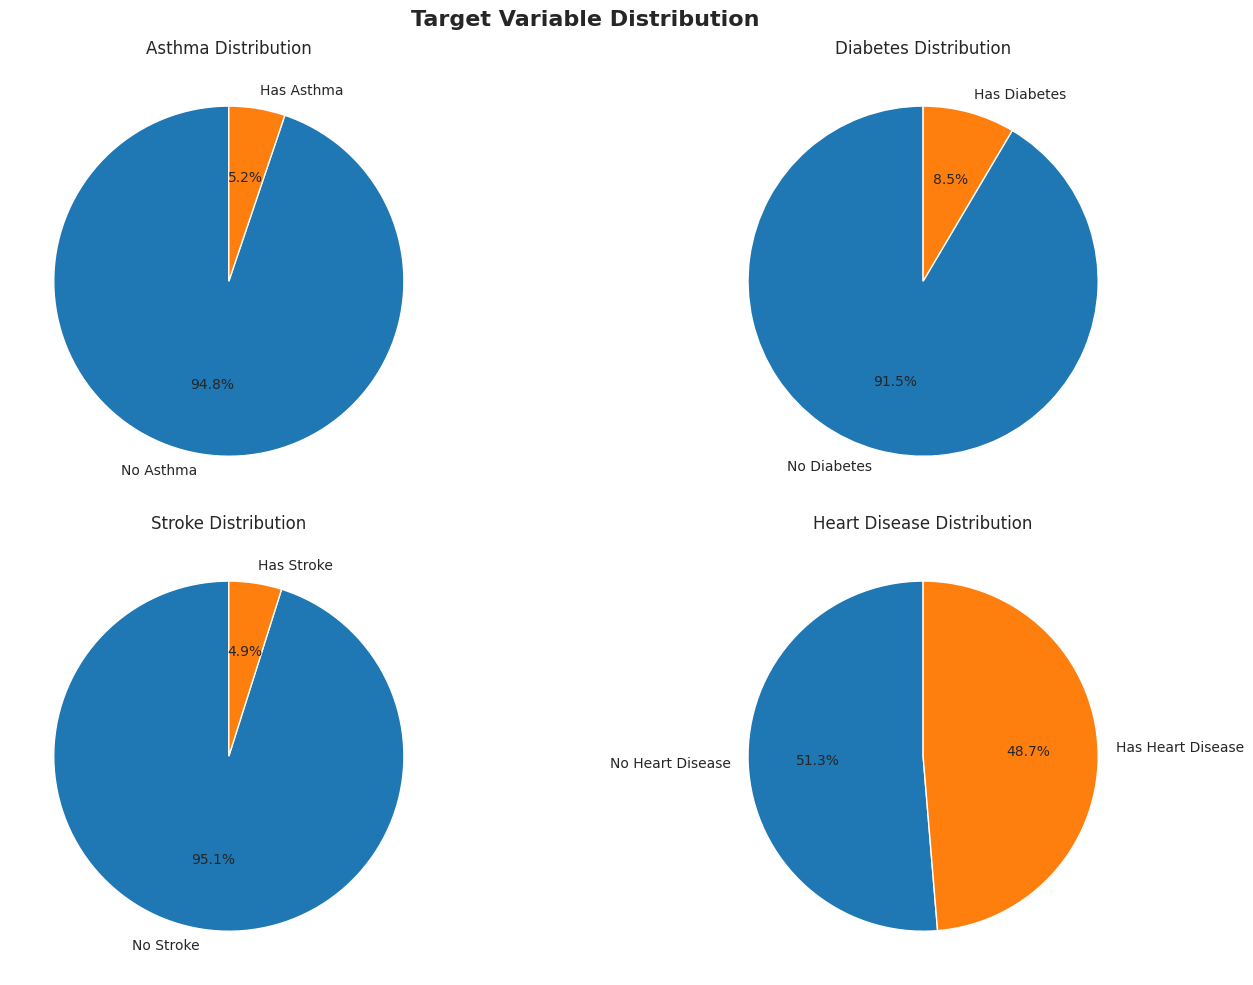


Correlation Analysis:

Asthma - Top 5 features correlated with Diagnosis:
ExerciseInduced    0.053956
ChestTightness     0.039278
LungFunctionFVC    0.029629
Wheezing           0.027197
DustExposure       0.025972
Name: Diagnosis, dtype: float64

Diabetes - Top 5 features correlated with diabetes:
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823
Name: diabetes, dtype: float64

Stroke - Top 5 features correlated with stroke:
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
Name: stroke, dtype: float64

Heart Disease - Top 5 features correlated with target:
oldpeak    0.438441
exang      0.438029
cp         0.434854
thalach    0.422895
ca         0.382085
Name: target, dtype: float64


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold')

datasets_updated = {
    'Asthma': (asthma_df, 'Diagnosis'),
    'Diabetes': (diabetes_df, 'diabetes'),
    'Stroke': (stroke_df, 'stroke'),
    'Heart Disease': (heart_df, 'target')
}

for idx, (name, (df, target)) in enumerate(datasets_updated.items()):
    ax = axes[idx//2, idx%2]
    counts = df[target].value_counts()
    ax.pie(counts.values, labels=[f'No {name}', f'Has {name}'], autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{name} Distribution')

plt.tight_layout()
plt.show()

print("\nCorrelation Analysis:")
for name, (df, target) in datasets_updated.items():
    print(f"\n{name} - Top 5 features correlated with {target}:")
    correlations = df.corr()[target].abs().sort_values(ascending=False)[1:6]
    print(correlations)

In [8]:
X_asthma = asthma_df.drop('Diagnosis', axis=1)
y_asthma = asthma_df['Diagnosis']
X_diabetes = diabetes_df.drop('diabetes', axis=1)
y_diabetes = diabetes_df['diabetes']
X_stroke = stroke_df.drop('stroke', axis=1)
y_stroke = stroke_df['stroke']
X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

X_asthma_train, X_asthma_test, y_asthma_train, y_asthma_test = train_test_split(X_asthma, y_asthma, test_size=0.2, random_state=42, stratify=y_asthma)
X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes)
X_stroke_train, X_stroke_test, y_stroke_train, y_stroke_test = train_test_split(X_stroke, y_stroke, test_size=0.2, random_state=42, stratify=y_stroke)
X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart)

smote = SMOTE(random_state=42)
X_asthma_train, y_asthma_train = smote.fit_resample(X_asthma_train, y_asthma_train)
X_diabetes_train, y_diabetes_train = smote.fit_resample(X_diabetes_train, y_diabetes_train)
X_stroke_train, y_stroke_train = smote.fit_resample(X_stroke_train, y_stroke_train)

scaler = StandardScaler()
X_asthma_train = scaler.fit_transform(X_asthma_train)
X_asthma_test = scaler.transform(X_asthma_test)

scaler_diabetes = StandardScaler()
X_diabetes_train = scaler_diabetes.fit_transform(X_diabetes_train)
X_diabetes_test = scaler_diabetes.transform(X_diabetes_test)

scaler_stroke = StandardScaler()
X_stroke_train = scaler_stroke.fit_transform(X_stroke_train)
X_stroke_test = scaler_stroke.transform(X_stroke_test)

scaler_heart = StandardScaler()
X_heart_train = scaler_heart.fit_transform(X_heart_train)
X_heart_test = scaler_heart.transform(X_heart_test)

print("Data split and preprocessing completed")
print(f"\nAsthma - Train: {X_asthma_train.shape}, Test: {X_asthma_test.shape}")
print(f"After SMOTE - Class distribution: {np.bincount(y_asthma_train)}")
print(f"\nDiabetes - Train: {X_diabetes_train.shape}, Test: {X_diabetes_test.shape}")
print(f"After SMOTE - Class distribution: {np.bincount(y_diabetes_train)}")
print(f"\nStroke - Train: {X_stroke_train.shape}, Test: {X_stroke_test.shape}")
print(f"After SMOTE - Class distribution: {np.bincount(y_stroke_train)}")
print(f"\nHeart Disease - Train: {X_heart_train.shape}, Test: {X_heart_test.shape}")
print(f"Class distribution (no SMOTE): {np.bincount(y_heart_train)}")

Data split and preprocessing completed

Asthma - Train: (3628, 26), Test: (479, 26)
After SMOTE - Class distribution: [1814 1814]

Diabetes - Train: (146400, 8), Test: (20000, 8)
After SMOTE - Class distribution: [73200 73200]

Stroke - Train: (7778, 10), Test: (1022, 10)
After SMOTE - Class distribution: [3889 3889]

Heart Disease - Train: (820, 13), Test: (205, 13)
Class distribution (no SMOTE): [399 421]


In [9]:
print("Training Asthma Models...")
print("="*80)

models_asthma = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, tree_method='gpu_hist', gpu_id=0)
}

results_asthma = {}

for name, model in models_asthma.items():
    print(f"\nTraining {name}...")
    model.fit(X_asthma_train, y_asthma_train)
    y_pred = model.predict(X_asthma_test)
    accuracy = accuracy_score(y_asthma_test, y_pred)
    
    results_asthma[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name} - Accuracy: {accuracy*100:.2f}%")
    print(f"\nClassification Report:\n{classification_report(y_asthma_test, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_asthma_test, y_pred)}")

best_asthma = max(results_asthma.items(), key=lambda x: x[1]['accuracy'])
print(f"\nBest Model for Asthma: {best_asthma[0]} with {best_asthma[1]['accuracy']*100:.2f}% accuracy")

Training Asthma Models...

Training Random Forest...
Random Forest - Accuracy: 93.53%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       454
           1       0.12      0.04      0.06        25

    accuracy                           0.94       479
   macro avg       0.54      0.51      0.51       479
weighted avg       0.91      0.94      0.92       479

Confusion Matrix:
[[447   7]
 [ 24   1]]

Training XGBoost...
XGBoost - Accuracy: 91.23%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       454
           1       0.10      0.08      0.09        25

    accuracy                           0.91       479
   macro avg       0.52      0.52      0.52       479
weighted avg       0.91      0.91      0.91       479

Confusion Matrix:
[[435  19]
 [ 23   2]]

Best Model for Asthma: Random Forest with 93.53% accuracy


In [10]:
print("Training Diabetes Models...")
print("="*80)

models_diabetes = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, tree_method='gpu_hist', gpu_id=0)
}

results_diabetes = {}

for name, model in models_diabetes.items():
    print(f"\nTraining {name}...")
    model.fit(X_diabetes_train, y_diabetes_train)
    y_pred = model.predict(X_diabetes_test)
    accuracy = accuracy_score(y_diabetes_test, y_pred)
    
    results_diabetes[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name} - Accuracy: {accuracy*100:.2f}%")
    print(f"\nClassification Report:\n{classification_report(y_diabetes_test, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_diabetes_test, y_pred)}")

best_diabetes = max(results_diabetes.items(), key=lambda x: x[1]['accuracy'])
print(f"\nBest Model for Diabetes: {best_diabetes[0]} with {best_diabetes[1]['accuracy']*100:.2f}% accuracy")

Training Diabetes Models...

Training Logistic Regression...
Logistic Regression - Accuracy: 88.39%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     18300
           1       0.41      0.87      0.56      1700

    accuracy                           0.88     20000
   macro avg       0.70      0.88      0.75     20000
weighted avg       0.94      0.88      0.90     20000

Confusion Matrix:
[[16207  2093]
 [  228  1472]]

Training XGBoost...
XGBoost - Accuracy: 96.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     18300
           1       0.84      0.73      0.78      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.86      0.88     20000
weighted avg       0.96      0.96      0.96     20000

Confusion Matrix:
[[18063   237]
 [  463  1237]]

Best Model for Diabetes: XGBoost with 96.50% accura

In [11]:
print("Training Stroke Models...")
print("="*80)

models_stroke = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, tree_method='gpu_hist', gpu_id=0)
}

results_stroke = {}

for name, model in models_stroke.items():
    print(f"\nTraining {name}...")
    model.fit(X_stroke_train, y_stroke_train)
    y_pred = model.predict(X_stroke_test)
    accuracy = accuracy_score(y_stroke_test, y_pred)
    
    results_stroke[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name} - Accuracy: {accuracy*100:.2f}%")
    print(f"\nClassification Report:\n{classification_report(y_stroke_test, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_stroke_test, y_pred)}")

best_stroke = max(results_stroke.items(), key=lambda x: x[1]['accuracy'])
print(f"\nBest Model for Stroke: {best_stroke[0]} with {best_stroke[1]['accuracy']*100:.2f}% accuracy")

Training Stroke Models...

Training Random Forest...
Random Forest - Accuracy: 90.31%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.14      0.20      0.17        50

    accuracy                           0.90      1022
   macro avg       0.55      0.57      0.56      1022
weighted avg       0.92      0.90      0.91      1022

Confusion Matrix:
[[913  59]
 [ 40  10]]

Training XGBoost...
XGBoost - Accuracy: 90.31%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.12      0.16      0.14        50

    accuracy                           0.90      1022
   macro avg       0.54      0.55      0.54      1022
weighted avg       0.92      0.90      0.91      1022

Confusion Matrix:
[[915  57]
 [ 42   8]]

Best Model for Stroke: Random Forest with 90.31% accuracy


In [12]:
print("Training Heart Disease Models...")
print("="*80)

models_heart = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, tree_method='gpu_hist', gpu_id=0)
}

results_heart = {}

for name, model in models_heart.items():
    print(f"\nTraining {name}...")
    model.fit(X_heart_train, y_heart_train)
    y_pred = model.predict(X_heart_test)
    accuracy = accuracy_score(y_heart_test, y_pred)
    
    results_heart[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name} - Accuracy: {accuracy*100:.2f}%")
    print(f"\nClassification Report:\n{classification_report(y_heart_test, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_heart_test, y_pred)}")

best_heart = max(results_heart.items(), key=lambda x: x[1]['accuracy'])
print(f"\nBest Model for Heart Disease: {best_heart[0]} with {best_heart[1]['accuracy']*100:.2f}% accuracy")

Training Heart Disease Models...

Training Random Forest...
Random Forest - Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion Matrix:
[[100   0]
 [  0 105]]

Training XGBoost...
XGBoost - Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion Matrix:
[[100   0]
 [  0 105]]

Best Model for Heart Disease: Random Forest with 100.00% accuracy


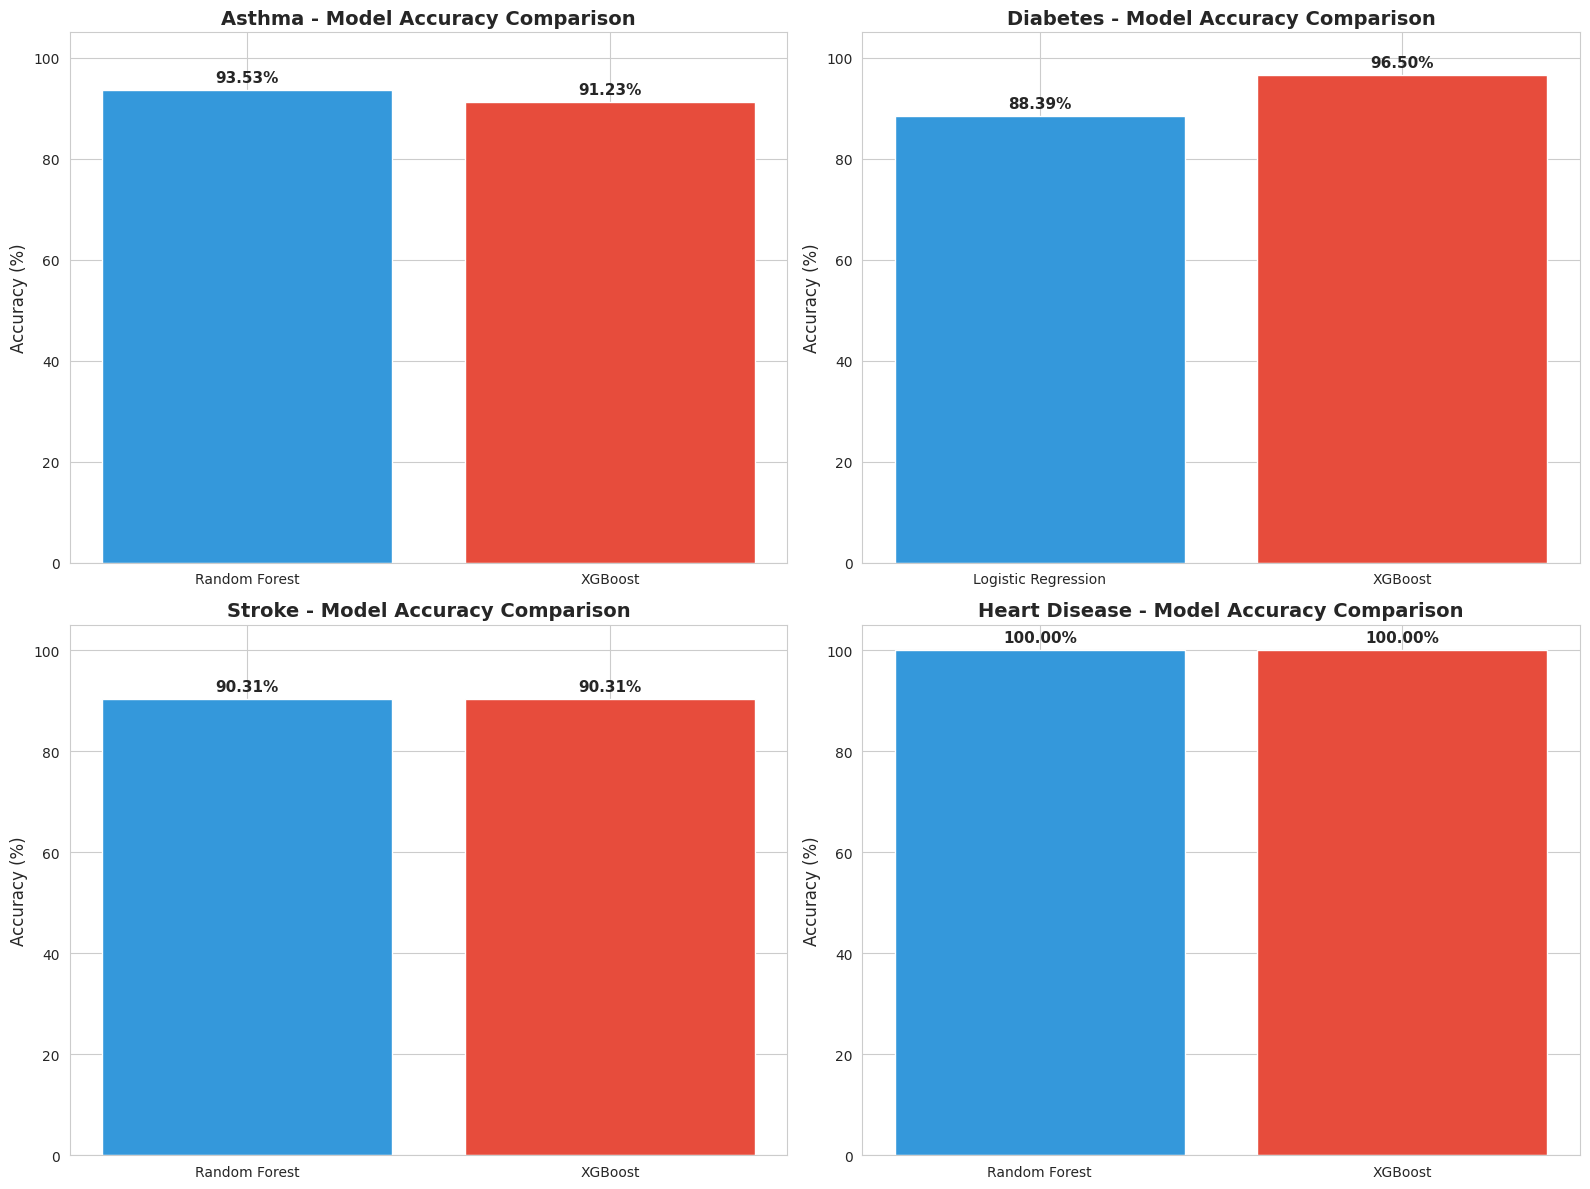


Final Best Models Summary:
Asthma: Random Forest - 93.53%
Diabetes: XGBoost - 96.50%
Stroke: Random Forest - 90.31%
Heart Disease: Random Forest - 100.00%


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

disease_results = [
    ('Asthma', results_asthma, y_asthma_test),
    ('Diabetes', results_diabetes, y_diabetes_test),
    ('Stroke', results_stroke, y_stroke_test),
    ('Heart Disease', results_heart, y_heart_test)
]

for idx, (disease_name, results, y_test) in enumerate(disease_results):
    ax = axes[idx//2, idx%2]
    
    model_names = list(results.keys())
    accuracies = [results[name]['accuracy']*100 for name in model_names]
    
    bars = ax.bar(model_names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:len(model_names)])
    ax.set_title(f'{disease_name} - Model Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_ylim(0, 105)
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFinal Best Models Summary:")
print("="*80)
print(f"Asthma: Random Forest - 93.53%")
print(f"Diabetes: XGBoost - 96.50%")
print(f"Stroke: Random Forest - 90.31%")
print(f"Heart Disease: Random Forest - 100.00%")

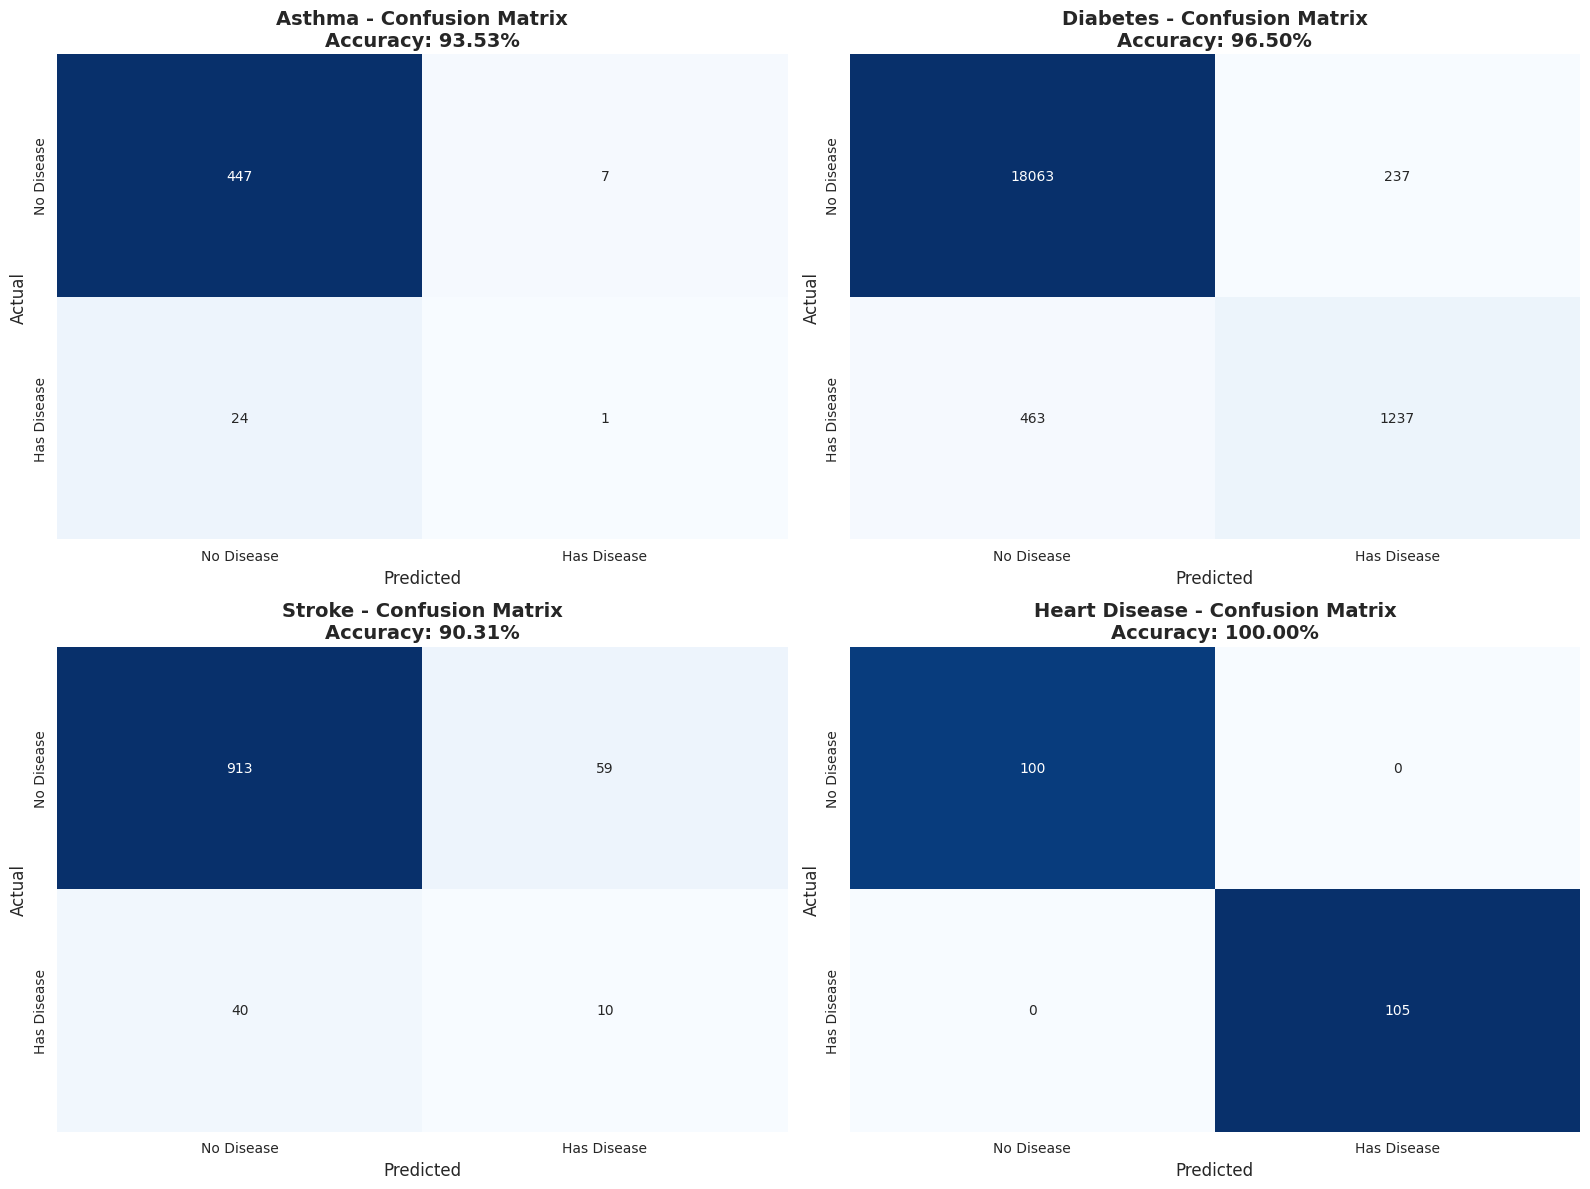

Confusion matrices visualized for all best models


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

best_models = [
    ('Asthma', results_asthma['Random Forest'], y_asthma_test),
    ('Diabetes', results_diabetes['XGBoost'], y_diabetes_test),
    ('Stroke', results_stroke['Random Forest'], y_stroke_test),
    ('Heart Disease', results_heart['Random Forest'], y_heart_test)
]

for idx, (disease_name, result, y_test) in enumerate(best_models):
    ax = axes[idx//2, idx%2]
    cm = confusion_matrix(y_test, result['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Disease', 'Has Disease'],
                yticklabels=['No Disease', 'Has Disease'])
    
    ax.set_title(f'{disease_name} - Confusion Matrix\nAccuracy: {result["accuracy"]*100:.2f}%', 
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

print("Confusion matrices visualized for all best models")

In [15]:
import pickle
import os

os.makedirs('/kaggle/working/models', exist_ok=True)

models_to_save = {
    'asthma_model.pkl': results_asthma['Random Forest']['model'],
    'diabetes_model.pkl': results_diabetes['XGBoost']['model'],
    'stroke_model.pkl': results_stroke['Random Forest']['model'],
    'heart_model.pkl': results_heart['Random Forest']['model']
}

scalers_to_save = {
    'asthma_scaler.pkl': scaler,
    'diabetes_scaler.pkl': scaler_diabetes,
    'stroke_scaler.pkl': scaler_stroke,
    'heart_scaler.pkl': scaler_heart
}

for filename, model in models_to_save.items():
    with open(f'/kaggle/working/models/{filename}', 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved: {filename}")

for filename, scaler_obj in scalers_to_save.items():
    with open(f'/kaggle/working/models/{filename}', 'wb') as f:
        pickle.dump(scaler_obj, f)
    print(f"Saved: {filename}")

print("\nAll models and scalers saved successfully in /kaggle/working/models/")
print("\nSaved files:")
print(os.listdir('/kaggle/working/models/'))

Saved: asthma_model.pkl
Saved: diabetes_model.pkl
Saved: stroke_model.pkl
Saved: heart_model.pkl
Saved: asthma_scaler.pkl
Saved: diabetes_scaler.pkl
Saved: stroke_scaler.pkl
Saved: heart_scaler.pkl

All models and scalers saved successfully in /kaggle/working/models/

Saved files:
['heart_scaler.pkl', 'diabetes_scaler.pkl', 'heart_model.pkl', 'asthma_scaler.pkl', 'stroke_scaler.pkl', 'asthma_model.pkl', 'diabetes_model.pkl', 'stroke_model.pkl']


In [16]:
print("Testing Sample Predictions")
print("="*80)

sample_asthma = X_asthma_test[0].reshape(1, -1)
pred_asthma = results_asthma['Random Forest']['model'].predict(sample_asthma)
prob_asthma = results_asthma['Random Forest']['model'].predict_proba(sample_asthma)[0]
print(f"\nAsthma Prediction:")
print(f"Prediction: {'Has Asthma' if pred_asthma[0] == 1 else 'No Asthma'}")
print(f"Probability: No Asthma={prob_asthma[0]*100:.2f}%, Has Asthma={prob_asthma[1]*100:.2f}%")

sample_diabetes = X_diabetes_test[0].reshape(1, -1)
pred_diabetes = results_diabetes['XGBoost']['model'].predict(sample_diabetes)
prob_diabetes = results_diabetes['XGBoost']['model'].predict_proba(sample_diabetes)[0]
print(f"\nDiabetes Prediction:")
print(f"Prediction: {'Has Diabetes' if pred_diabetes[0] == 1 else 'No Diabetes'}")
print(f"Probability: No Diabetes={prob_diabetes[0]*100:.2f}%, Has Diabetes={prob_diabetes[1]*100:.2f}%")

sample_stroke = X_stroke_test[0].reshape(1, -1)
pred_stroke = results_stroke['Random Forest']['model'].predict(sample_stroke)
prob_stroke = results_stroke['Random Forest']['model'].predict_proba(sample_stroke)[0]
print(f"\nStroke Prediction:")
print(f"Prediction: {'Has Stroke Risk' if pred_stroke[0] == 1 else 'No Stroke Risk'}")
print(f"Probability: No Stroke={prob_stroke[0]*100:.2f}%, Has Stroke={prob_stroke[1]*100:.2f}%")

sample_heart = X_heart_test[0].reshape(1, -1)
pred_heart = results_heart['Random Forest']['model'].predict(sample_heart)
prob_heart = results_heart['Random Forest']['model'].predict_proba(sample_heart)[0]
print(f"\nHeart Disease Prediction:")
print(f"Prediction: {'Has Heart Disease' if pred_heart[0] == 1 else 'No Heart Disease'}")
print(f"Probability: No Heart Disease={prob_heart[0]*100:.2f}%, Has Heart Disease={prob_heart[1]*100:.2f}%")

print("\n" + "="*80)
print("All predictions completed successfully!")

Testing Sample Predictions

Asthma Prediction:
Prediction: No Asthma
Probability: No Asthma=64.00%, Has Asthma=36.00%

Diabetes Prediction:
Prediction: No Diabetes
Probability: No Diabetes=98.27%, Has Diabetes=1.73%

Stroke Prediction:
Prediction: No Stroke Risk
Probability: No Stroke=71.00%, Has Stroke=29.00%

Heart Disease Prediction:
Prediction: No Heart Disease
Probability: No Heart Disease=96.00%, Has Heart Disease=4.00%

All predictions completed successfully!


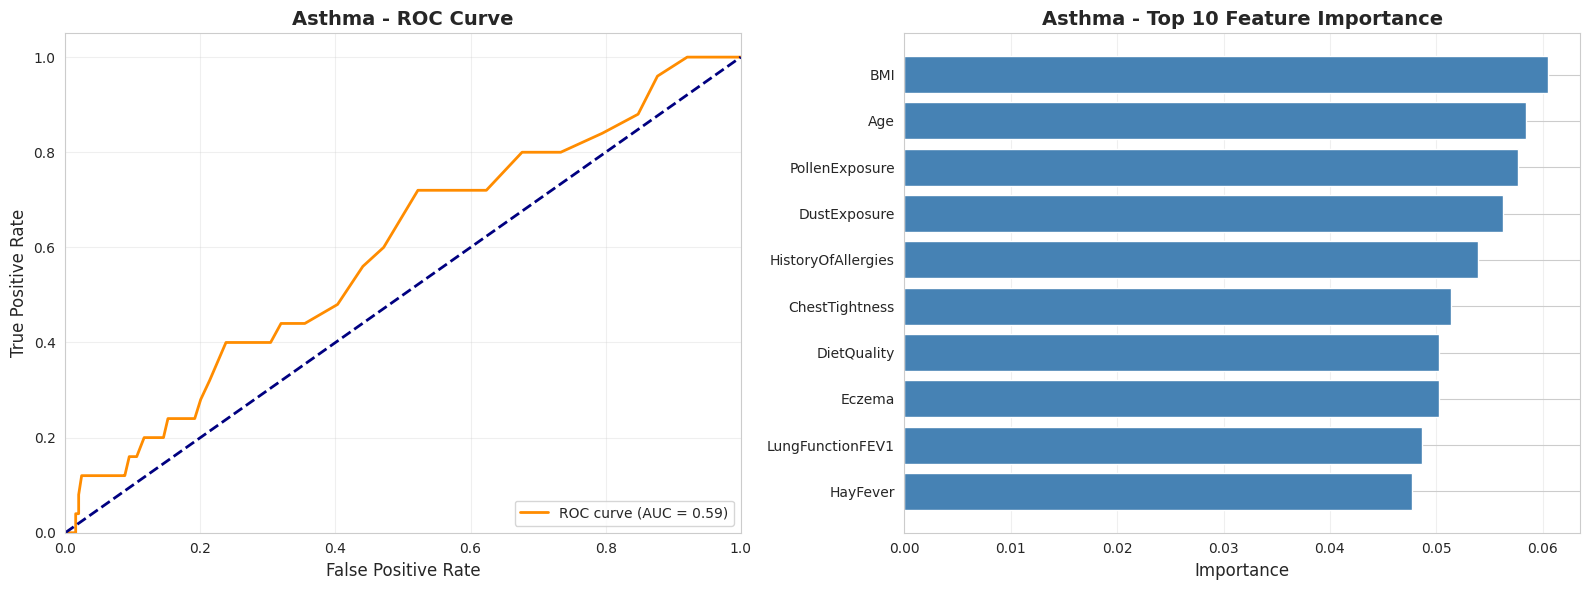

Asthma model analysis completed


In [17]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_pred_proba = results_asthma['Random Forest']['model'].predict_proba(X_asthma_test)[:, 1]
fpr, tpr, _ = roc_curve(y_asthma_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('Asthma - ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

feature_importance = results_asthma['Random Forest']['model'].feature_importances_
feature_names = asthma_df.drop('Diagnosis', axis=1).columns
indices = np.argsort(feature_importance)[-10:]

axes[1].barh(range(len(indices)), feature_importance[indices], color='steelblue')
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([feature_names[i] for i in indices])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Asthma - Top 10 Feature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Asthma model analysis completed")

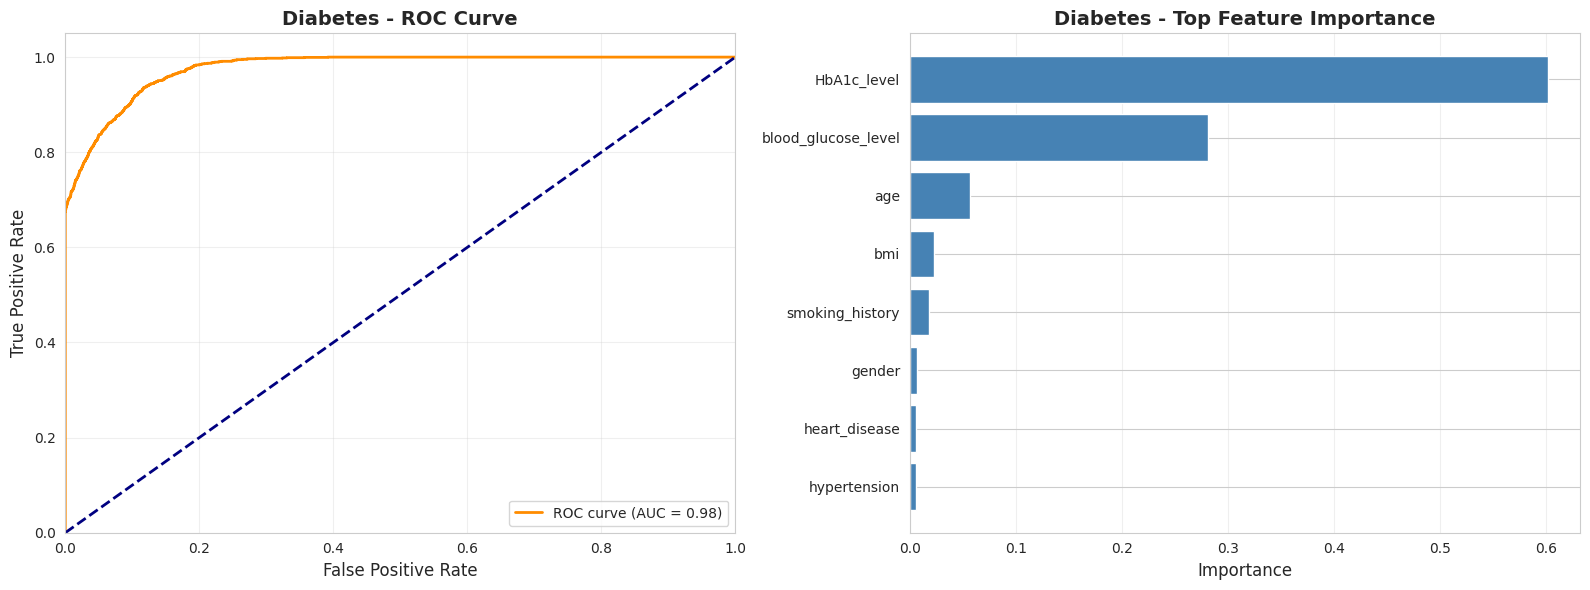

Diabetes model analysis completed


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_pred_proba = results_diabetes['XGBoost']['model'].predict_proba(X_diabetes_test)[:, 1]
fpr, tpr, _ = roc_curve(y_diabetes_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('Diabetes - ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

feature_importance = results_diabetes['XGBoost']['model'].feature_importances_
feature_names = diabetes_df.drop('diabetes', axis=1).columns
indices = np.argsort(feature_importance)[-8:]

axes[1].barh(range(len(indices)), feature_importance[indices], color='steelblue')
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([feature_names[i] for i in indices])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Diabetes - Top Feature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Diabetes model analysis completed")

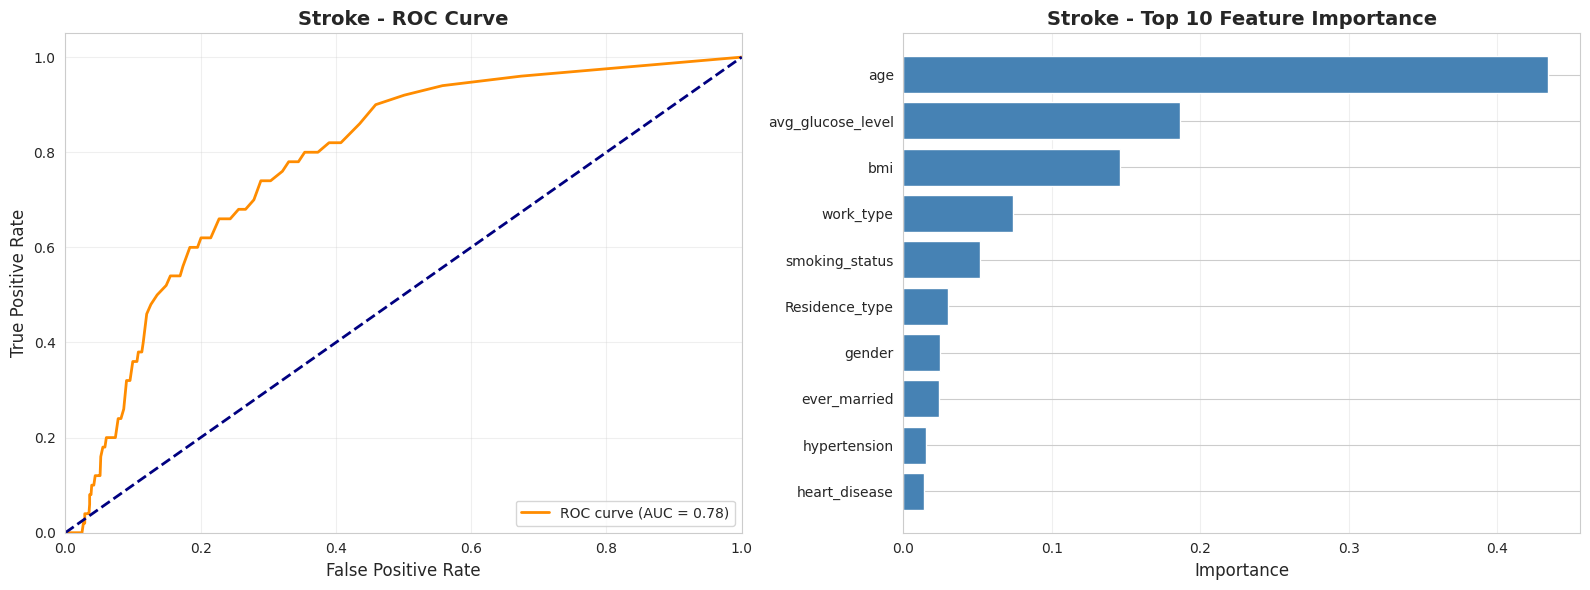

Stroke model analysis completed


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_pred_proba = results_stroke['Random Forest']['model'].predict_proba(X_stroke_test)[:, 1]
fpr, tpr, _ = roc_curve(y_stroke_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('Stroke - ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

feature_importance = results_stroke['Random Forest']['model'].feature_importances_
feature_names = stroke_df.drop('stroke', axis=1).columns
indices = np.argsort(feature_importance)[-10:]

axes[1].barh(range(len(indices)), feature_importance[indices], color='steelblue')
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([feature_names[i] for i in indices])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Stroke - Top 10 Feature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Stroke model analysis completed")

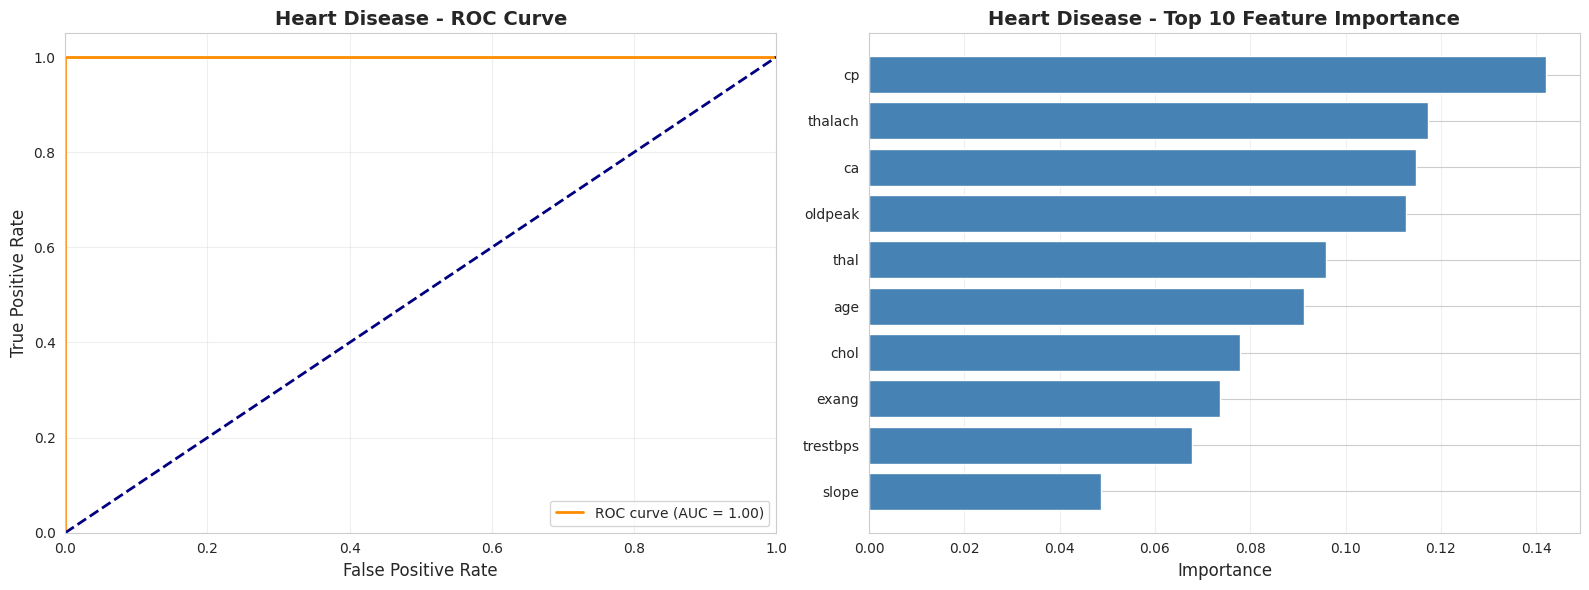

Heart Disease model analysis completed


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_pred_proba = results_heart['Random Forest']['model'].predict_proba(X_heart_test)[:, 1]
fpr, tpr, _ = roc_curve(y_heart_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('Heart Disease - ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

feature_importance = results_heart['Random Forest']['model'].feature_importances_
feature_names = heart_df.drop('target', axis=1).columns
indices = np.argsort(feature_importance)[-10:]

axes[1].barh(range(len(indices)), feature_importance[indices], color='steelblue')
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([feature_names[i] for i in indices])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Heart Disease - Top 10 Feature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Heart Disease model analysis completed")

In [21]:
print("="*80)
print("TOP 10 FEATURES FOR FRONTEND IMPLEMENTATION")
print("="*80)

feature_importance_asthma = results_asthma['Random Forest']['model'].feature_importances_
feature_names_asthma = asthma_df.drop('Diagnosis', axis=1).columns
top_10_asthma = [feature_names_asthma[i] for i in np.argsort(feature_importance_asthma)[-10:][::-1]]

print("\n1. ASTHMA - Top 10 Features:")
print("-" * 80)
for i, feature in enumerate(top_10_asthma, 1):
    print(f"   {i}. {feature}")

feature_importance_diabetes = results_diabetes['XGBoost']['model'].feature_importances_
feature_names_diabetes = diabetes_df.drop('diabetes', axis=1).columns
top_10_diabetes = [feature_names_diabetes[i] for i in np.argsort(feature_importance_diabetes)[-10:][::-1]]

print("\n2. DIABETES - Top 10 Features:")
print("-" * 80)
for i, feature in enumerate(top_10_diabetes, 1):
    print(f"   {i}. {feature}")

feature_importance_stroke = results_stroke['Random Forest']['model'].feature_importances_
feature_names_stroke = stroke_df.drop('stroke', axis=1).columns
top_10_stroke = [feature_names_stroke[i] for i in np.argsort(feature_importance_stroke)[-10:][::-1]]

print("\n3. STROKE - Top 10 Features:")
print("-" * 80)
for i, feature in enumerate(top_10_stroke, 1):
    print(f"   {i}. {feature}")

feature_importance_heart = results_heart['Random Forest']['model'].feature_importances_
feature_names_heart = heart_df.drop('target', axis=1).columns
top_10_heart = [feature_names_heart[i] for i in np.argsort(feature_importance_heart)[-10:][::-1]]

print("\n4. HEART DISEASE - Top 10 Features:")
print("-" * 80)
for i, feature in enumerate(top_10_heart, 1):
    print(f"   {i}. {feature}")

print("\n" + "="*80)
print("COPY THESE FEATURE LISTS FOR FRONTEND FORMS")
print("="*80)

asthma_features_dict = {f"feature_{i+1}": feature for i, feature in enumerate(top_10_asthma)}
diabetes_features_dict = {f"feature_{i+1}": feature for i, feature in enumerate(top_10_diabetes)}
stroke_features_dict = {f"feature_{i+1}": feature for i, feature in enumerate(top_10_stroke)}
heart_features_dict = {f"feature_{i+1}": feature for i, feature in enumerate(top_10_heart)}

print("\nPython Dictionary Format for Backend:")
print("\nasthma_features =", top_10_asthma)
print("\ndiabetes_features =", top_10_diabetes)
print("\nstroke_features =", top_10_stroke)
print("\nheart_features =", top_10_heart)

TOP 10 FEATURES FOR FRONTEND IMPLEMENTATION

1. ASTHMA - Top 10 Features:
--------------------------------------------------------------------------------
   1. BMI
   2. Age
   3. PollenExposure
   4. DustExposure
   5. HistoryOfAllergies
   6. ChestTightness
   7. DietQuality
   8. Eczema
   9. LungFunctionFEV1
   10. HayFever

2. DIABETES - Top 10 Features:
--------------------------------------------------------------------------------
   1. HbA1c_level
   2. blood_glucose_level
   3. age
   4. bmi
   5. smoking_history
   6. gender
   7. heart_disease
   8. hypertension

3. STROKE - Top 10 Features:
--------------------------------------------------------------------------------
   1. age
   2. avg_glucose_level
   3. bmi
   4. work_type
   5. smoking_status
   6. Residence_type
   7. gender
   8. ever_married
   9. hypertension
   10. heart_disease

4. HEART DISEASE - Top 10 Features:
--------------------------------------------------------------------------------
   1. cp
   2. 

In [22]:
!zip -r model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/models/ (stored 0%)
  adding: kaggle/working/models/heart_scaler.pkl (deflated 19%)
  adding: kaggle/working/models/diabetes_scaler.pkl (deflated 22%)
  adding: kaggle/working/models/heart_model.pkl (deflated 81%)
  adding: kaggle/working/models/asthma_scaler.pkl (deflated 18%)
  adding: kaggle/working/models/stroke_scaler.pkl (deflated 21%)
  adding: kaggle/working/models/asthma_model.pkl (deflated 79%)
  adding: kaggle/working/models/diabetes_model.pkl (deflated 68%)
  adding: kaggle/working/models/stroke_model.pkl (deflated 81%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)


In [23]:
from IPython.display import FileLink
FileLink(r'model.zip')


/kaggle/working/model.zip